<a href="https://colab.research.google.com/github/VahidehRajaei/Deep-Learning-Exercises/blob/main/Rock_Paper_Scissors/rock_paper_scissors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import random
import matplotlib.image as mpimg
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [3]:
BASE_DIR = '/content/drive/MyDrive/rps/rps_dataset/'

PAPER_DIR = os.path.join(BASE_DIR, 'paper')
ROCK_DIR = os.path.join(BASE_DIR, 'rock')
SCISSORS_DIR = os.path.join(BASE_DIR, 'scissors')

In [4]:
print(f"Total paper images: {len(os.listdir(PAPER_DIR))}")
print(f"Total rock images: {len(os.listdir(ROCK_DIR))}")
print(f"Total scissors images: {len(os.listdir(SCISSORS_DIR))}")

Total paper images: 712
Total rock images: 726
Total scissors images: 750


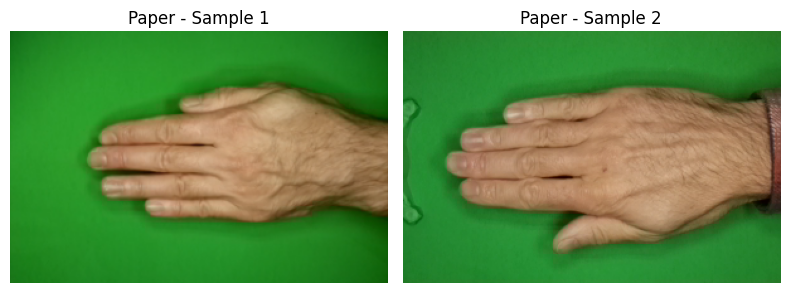

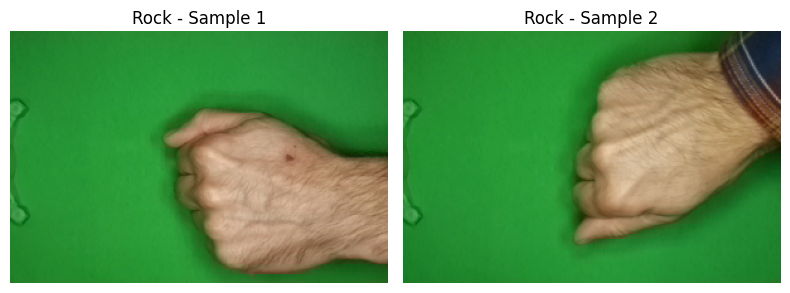

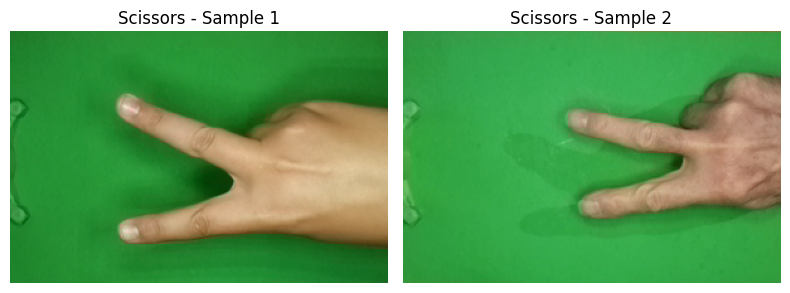

In [5]:
def visualize_two_sample_images(directory, title="Sample Images"):

   # Get a list of all images in the folder
    filenames = os.listdir(directory)

    sample_images = random.sample(filenames, 2)

    plt.figure(figsize=(8, 4))

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(directory, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(1, 2, i + 1)
        plt.imshow(img)
        plt.title(f"{title} - Sample {i + 1}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_two_sample_images(PAPER_DIR, title="Paper")
visualize_two_sample_images(ROCK_DIR, title="Rock")
visualize_two_sample_images(SCISSORS_DIR, title="Scissors")

In [6]:
# Specify the size of the images and the size of each batch
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Loading training data (80%) as One-Hot Encoded
train_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'

)

# Loading validation data (20%) as One-Hot Encoded
val_ds = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 2188 files belonging to 3 classes.
Using 1751 files for training.
Found 2188 files belonging to 3 classes.
Using 437 files for validation.


In [7]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

In [8]:
model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),


    data_augmentation,


    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),


    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),


    layers.Dense(3, activation='softmax')
])

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
class_names = train_ds.class_names
print("Class names:", class_names)

Class names: ['paper', 'rock', 'scissors']


In [11]:
for image_batch, labels_batch in train_ds.take(1):
    print("Image batch shape:", image_batch.shape)
    print("Labels batch shape:", labels_batch.shape)

Image batch shape: (32, 150, 150, 3)
Labels batch shape: (32, 3)


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

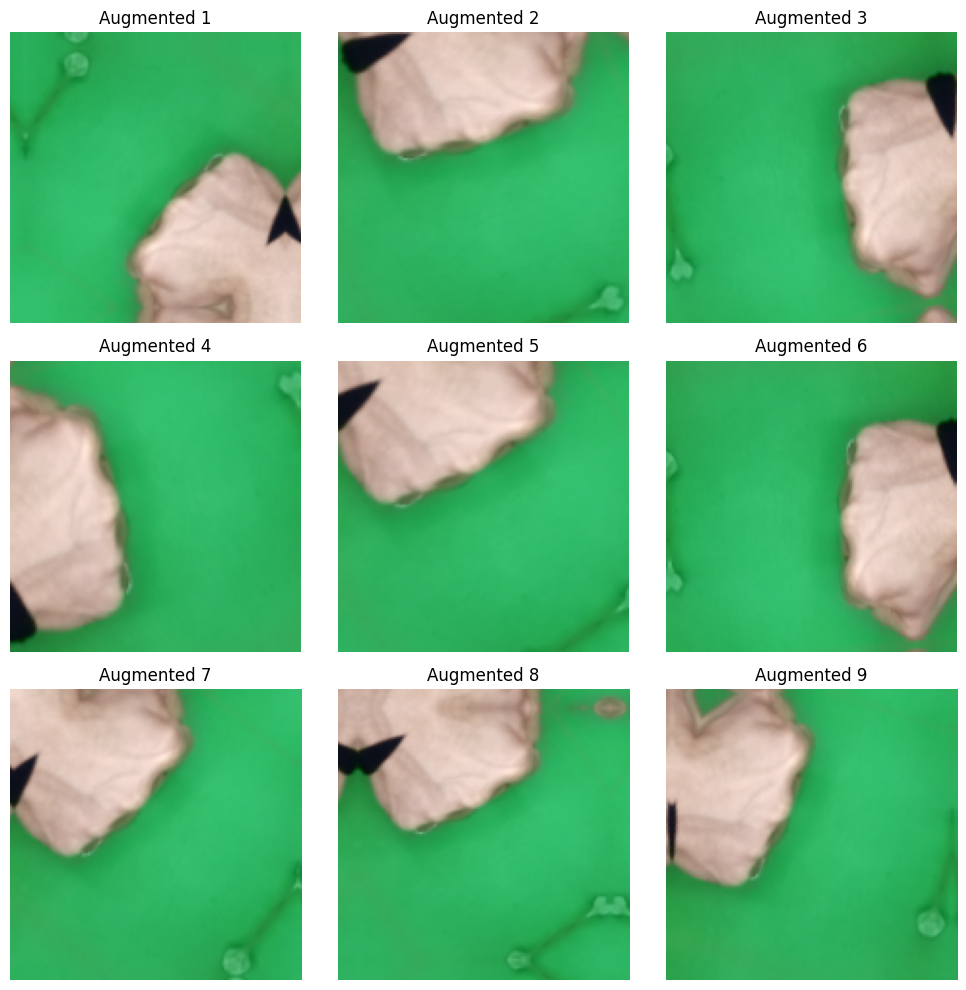

In [14]:
def visualize_augmented_images(dataset, augmentation_layer, num_samples=9):

    # Get a batch of images from the dataset
    for images, _ in dataset.take(1):

        # Selecting the first image to display various changes applied to it
        first_image = images[0]

        plt.figure(figsize=(10, 10))
        for i in range(num_samples):

            augmented_image = augmentation_layer(tf.expand_dims(first_image, 0))

            ax = plt.subplot(3, 3, i + 1)

            # If the values ​​are between 0 and 255, they are converted to uint8 format to ensure correct display.
            plt.imshow(augmented_image[0].numpy().astype("uint8"))
            plt.title(f"Augmented {i + 1}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

visualize_augmented_images(train_ds, data_augmentation)

In [15]:
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)

In [16]:
model = keras.Sequential([
    layers.Input(shape=(150, 150, 3)),

    data_augmentation,

    # Convolution and Max-Pooling Blocks (Feature Extraction)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected (Dense) Layers and Dropout
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

   # Output layer for 3 classes with Softmax activation function
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,035,203 (72.61 MB)

 Trainable params: 19,035,203 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.4249 - loss: 1.0753 - val_accuracy: 0.6751 - val_loss: 0.8376
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6653 - loss: 0.7797 - val_accuracy: 0.7529 - val_loss: 0.6156
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7681 - loss: 0.5821 - val_accuracy: 0.8787 - val_loss: 0.3572
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7898 - loss: 0.5268 - val_accuracy: 0.8902 - val_loss: 0.3282
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.8561 - loss: 0.3814 - val_accuracy: 0.9474 - val_loss: 0.1828
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9058 - loss: 0.2851 - val_accuracy: 0.9611 - val_loss: 0.1457
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8806 - loss: 0.3225 - val_accuracy: 0.9588 - val_loss: 0.1431
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9041 - loss: 0.2684 - val_accuracy: 0.9130 - v

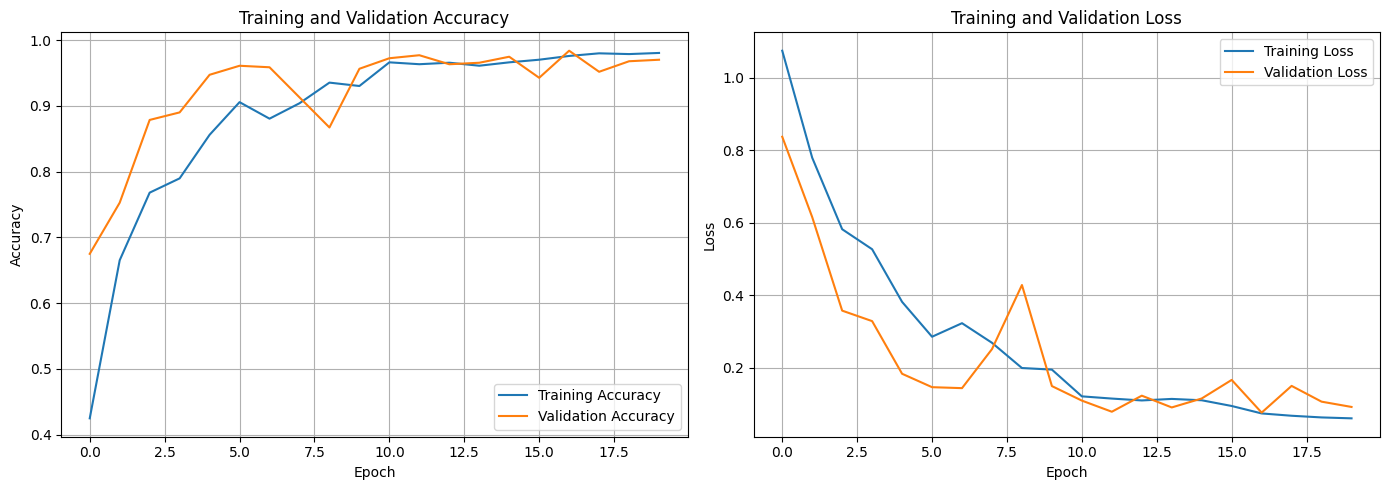

In [19]:
def plot_training_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Chart 1: Training and Validation Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)

    # Chart 2: Training and Validation Error
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step


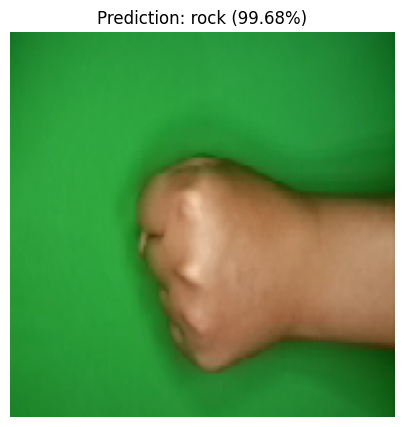

Predicted: rock with 99.68% confidence


In [20]:
def predict_image(model, image_path, class_names, img_size=(150, 150)):

    # Upload image with specified size
    img = keras.utils.load_img(image_path, target_size=img_size)

    # Converting the image to an array and applying normalization similar to the previous step
    img_array = keras.utils.img_to_array(img)
    img_array = img_array / 255.0

    # Add a batch dimension to the image (convert to 1, H, W, C)
    img_batch = tf.expand_dims(img_array, 0)

    # Prediction with the model
    predictions = model.predict(img_batch)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class = class_names[predicted_class_index]
    confidence = 100 * np.max(predictions[0])

    # Display the image with the predicted class and confidence percentage
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence

# Selecting a sample photo for testing
sample_img_path = os.path.join(ROCK_DIR, os.listdir(ROCK_DIR)[0])

pred_class, conf = predict_image(model, sample_img_path, class_names, img_size=(150, 150))
print(f"Predicted: {pred_class} with {conf:.2f}% confidence")